In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix
)

# ============================================================
# CONSTANTS
# ============================================================
RANDOM_STATE = 42

# Path dataset
DATASET_PATH = r"D:\UNIVERSITAS INDONESIA\Bimbingan 2026\Icha\dataset_fix.xlsx"

# Output directory
OUTPUT_DIR = r"D:\UNIVERSITAS INDONESIA\Bimbingan 2026\Icha\outputFDD_TANPAMULTIVARIAT"
os.makedirs(OUTPUT_DIR, exist_ok=True)

STAGE1_DIR = os.path.join(OUTPUT_DIR, "stage1_fault_detection")
STAGE2_DIR = os.path.join(OUTPUT_DIR, "stage2_fault_diagnosis")
os.makedirs(STAGE1_DIR, exist_ok=True)
os.makedirs(STAGE2_DIR, exist_ok=True)

ALL_FEATURES = [
    # Distribution (8)
    'temp_mean', 'temp_std', 'temp_min', 'temp_max', 'temp_range',
    'temp_skew', 'temp_kurt', 'temp_cv',
    # Rate (4)
    'delta_T_mean', 'delta_T_std', 'delta_T_abs_max', 'delta_T_per_minute_max',
    # Persistence (2)
    'consecutive_identical', '1h_unique_ratio',
    # Statistical (1)
    'temp_zscore_max',
    # Cyclical (4)
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    # Data quality (2)
    'n_gaps', 'max_gap_minute',
]

print(f"Total fitur: {len(ALL_FEATURES)}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Dataset    : {DATASET_PATH}")

Total fitur: 21
Output dir : D:\UNIVERSITAS INDONESIA\Bimbingan 2026\Icha\outputFDD_TANPAMULTIVARIAT
Dataset    : D:\UNIVERSITAS INDONESIA\Bimbingan 2026\Icha\dataset_fix.xlsx


In [11]:
# Cek NaN per fitur

df_dataset = pd.read_excel(DATASET_PATH)
print("\n--- NaN audit ---")
nan_per_col = df_dataset[ALL_FEATURES].isna().sum().sort_values(ascending=False)
nan_per_col = nan_per_col[nan_per_col > 0]
if len(nan_per_col) == 0:
    print("Tidak ada NaN di fitur ML")
else:
    print(f"Fitur yang punya NaN:")
    print(nan_per_col.to_string())

# Drop rows dengan NaN
nan_mask = df_dataset[ALL_FEATURES].isna().any(axis=1)
print(f"\nBaris dengan NaN: {nan_mask.sum()} ({nan_mask.sum()/len(df_dataset)*100:.2f}%)")
print(f"Breakdown per kelas yang akan di-drop:")
print(df_dataset[nan_mask]['CLASS'].value_counts().to_string())

df_dataset = df_dataset[~nan_mask].reset_index(drop=True)

print(f"\nSetelah drop NaN: {len(df_dataset)} baris")
print(f"Distribusi akhir:")
print(df_dataset['CLASS'].value_counts().to_string())


--- NaN audit ---
Fitur yang punya NaN:
temp_kurt          322
temp_skew          173
delta_T_std        173
temp_zscore_max     16

Baris dengan NaN: 324 (0.47%)
Breakdown per kelas yang akan di-drop:
CLASS
COMM_FAULT    315
FAILURE         8
ANOMALI         1

Setelah drop NaN: 67964 baris
Distribusi akhir:
CLASS
NORMAL        34144
COMM_FAULT    24669
FAILURE        8310
ANOMALI         841


In [12]:
# ============================================================
# STEP 2: STAGE 1 SETUP - BINARY LABELS + SPLIT + SCALING
# ============================================================
# >>> Stage 1 = FAULT DETECTION → pakai kolom 'health condition' <
#     0 = NORMAL, 1 = ABNORMAL (FAILURE / COMM_FAULT / ANOMALI)
df_stage1 = df_dataset.copy()

# Validasi kolom 'health condition' ada di dataset
assert 'health condition' in df_stage1.columns, "Kolom 'health condition' tidak ada di dataset!"

# Cross-check konsistensi 'health condition' vs 'CLASS' (jaga-jaga)
hc_check = df_stage1.groupby('CLASS')['health condition'].agg(['min', 'max', 'nunique'])
print("Cross-check 'health condition' vs 'CLASS':")
print(hc_check)
assert (df_stage1.loc[df_stage1['CLASS'] == 'NORMAL', 'health condition'] == 0).all(), "NORMAL harus health=0"
assert (df_stage1.loc[df_stage1['CLASS'] != 'NORMAL', 'health condition'] == 1).all(), "non-NORMAL harus health=1"
print("[OK] 'health condition' konsisten dengan 'CLASS'")

# Untuk Stage 1, label = 'health condition' langsung
df_stage1['BINARY_NAME'] = df_stage1['health condition'].map({0: 'NORMAL', 1: 'ABNORMAL'})

print(f"\nDistribusi 'health condition' (label Stage 1):")
print(df_stage1['BINARY_NAME'].value_counts().to_string())
print(f"\nKomposisi ABNORMAL (health condition = 1) — breakdown per CLASS:")
print(df_stage1[df_stage1['health condition'] == 1]['CLASS'].value_counts().to_string())

# Pisah NORMAL & ABNORMAL berdasar 'health condition'
df_normal   = df_stage1[df_stage1['health condition'] == 0].reset_index(drop=True)
df_abnormal = df_stage1[df_stage1['health condition'] == 1].reset_index(drop=True)

# Split NORMAL: 70:15:15
n_normal_train = int(len(df_normal) * 0.70)
n_normal_val   = int(len(df_normal) * 0.15)
df_normal_shuffled = df_normal.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df_normal_train = df_normal_shuffled.iloc[:n_normal_train]
df_normal_val   = df_normal_shuffled.iloc[n_normal_train:n_normal_train + n_normal_val]
df_normal_test  = df_normal_shuffled.iloc[n_normal_train + n_normal_val:]

# Split ABNORMAL: 50:50 (val:test) — train hanya NORMAL (one-class!)
df_abnormal_shuffled = df_abnormal.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
n_abnormal_val = len(df_abnormal_shuffled) // 2
df_abnormal_val  = df_abnormal_shuffled.iloc[:n_abnormal_val]
df_abnormal_test = df_abnormal_shuffled.iloc[n_abnormal_val:]

# Build sets
df_train_s1 = df_normal_train.reset_index(drop=True)
df_val_s1   = pd.concat([df_normal_val, df_abnormal_val]).reset_index(drop=True)
df_test_s1  = pd.concat([df_normal_test, df_abnormal_test]).reset_index(drop=True)

print(f"\n=== Stage 1 Split ===")
print(f"Train      : {len(df_train_s1)} (NORMAL only)")
print(f"Validation : {len(df_val_s1)} ({len(df_normal_val)} N + {len(df_abnormal_val)} A)")
for cls in ['ANOMALI', 'FAILURE', 'COMM_FAULT']:
    print(f"  {cls:10s}: {(df_val_s1['CLASS'] == cls).sum()}")
print(f"Test       : {len(df_test_s1)} ({len(df_normal_test)} N + {len(df_abnormal_test)} A)")
for cls in ['ANOMALI', 'FAILURE', 'COMM_FAULT']:
    print(f"  {cls:10s}: {(df_test_s1['CLASS'] == cls).sum()}")

# Extract X, y — y_*_s1 = 'health condition'
X_train_s1 = df_train_s1[ALL_FEATURES].copy()
X_val_s1   = df_val_s1[ALL_FEATURES].copy()
X_test_s1  = df_test_s1[ALL_FEATURES].copy()

y_train_s1 = df_train_s1['health condition'].values
y_val_s1   = df_val_s1['health condition'].values
y_test_s1  = df_test_s1['health condition'].values

# Scaling — fit di train (NORMAL only), transform val & test
scaler_s1 = StandardScaler()
X_train_s1_scaled = pd.DataFrame(scaler_s1.fit_transform(X_train_s1),
                                  columns=X_train_s1.columns, index=X_train_s1.index)
X_val_s1_scaled   = pd.DataFrame(scaler_s1.transform(X_val_s1),
                                  columns=X_val_s1.columns, index=X_val_s1.index)
X_test_s1_scaled  = pd.DataFrame(scaler_s1.transform(X_test_s1),
                                  columns=X_test_s1.columns, index=X_test_s1.index)

assert X_train_s1_scaled.isna().sum().sum() == 0, "NaN di train!"
assert X_val_s1_scaled.isna().sum().sum() == 0,   "NaN di val!"
assert X_test_s1_scaled.isna().sum().sum() == 0,  "NaN di test!"
print("\n[OK] Tidak ada NaN di train/val/test setelah scaling")
print("[OK] Stage 1 menggunakan label dari kolom 'health condition'")

Cross-check 'health condition' vs 'CLASS':
            min  max  nunique
CLASS                        
ANOMALI       1    1        1
COMM_FAULT    1    1        1
FAILURE       1    1        1
NORMAL        0    0        1
[OK] 'health condition' konsisten dengan 'CLASS'

Distribusi 'health condition' (label Stage 1):
BINARY_NAME
NORMAL      34144
ABNORMAL    33820

Komposisi ABNORMAL (health condition = 1) — breakdown per CLASS:
CLASS
COMM_FAULT    24669
FAILURE        8310
ANOMALI         841

=== Stage 1 Split ===
Train      : 23900 (NORMAL only)
Validation : 22031 (5121 N + 16910 A)
  ANOMALI   : 427
  FAILURE   : 4163
  COMM_FAULT: 12320
Test       : 22033 (5123 N + 16910 A)
  ANOMALI   : 414
  FAILURE   : 4147
  COMM_FAULT: 12349

[OK] Tidak ada NaN di train/val/test setelah scaling
[OK] Stage 1 menggunakan label dari kolom 'health condition'


In [13]:
s1_data = []
for split_name, df_split in [('Train', df_train_s1),
                              ('Validation', df_val_s1),
                              ('Test', df_test_s1)]:
    n_normal = (df_split['health condition'] == 0).sum()
    n_abnormal = (df_split['health condition'] == 1).sum()
    # Breakdown ABNORMAL per CLASS
    n_anomali = (df_split['CLASS'] == 'ANOMALI').sum()
    n_failure = (df_split['CLASS'] == 'FAILURE').sum()
    n_comm    = (df_split['CLASS'] == 'COMM_FAULT').sum()
    s1_data.append({
        'Split': split_name,
        'NORMAL': n_normal,
        'ABNORMAL': n_abnormal,
        'ANOMALI': n_anomali,
        'FAILURE': n_failure,
        'COMM_FAULT': n_comm,
        'Total': len(df_split),
    })

df_s1_summary = pd.DataFrame(s1_data)
print(df_s1_summary.to_string(index=False))

print(f"X_train_s1_scaled.shape: {X_train_s1_scaled.shape}")
print(f"X_val_s1_scaled.shape:   {X_val_s1_scaled.shape}")
print(f"X_test_s1_scaled.shape:  {X_test_s1_scaled.shape}")

     Split  NORMAL  ABNORMAL  ANOMALI  FAILURE  COMM_FAULT  Total
     Train   23900         0        0        0           0  23900
Validation    5121     16910      427     4163       12320  22031
      Test    5123     16910      414     4147       12349  22033
X_train_s1_scaled.shape: (23900, 21)
X_val_s1_scaled.shape:   (22031, 21)
X_test_s1_scaled.shape:  (22033, 21)


               feature  importance
        max_gap_minute    0.311778
                n_gaps    0.242028
              temp_min    0.057810
 consecutive_identical    0.049197
             temp_mean    0.046198
              temp_max    0.045714
            temp_range    0.034582
               temp_cv    0.032884
       1h_unique_ratio    0.029537
           delta_T_std    0.027503
             month_sin    0.026769
delta_T_per_minute_max    0.025143
       delta_T_abs_max    0.020272
              temp_std    0.014368
          delta_T_mean    0.008240
             month_cos    0.007818
       temp_zscore_max    0.005063
             temp_kurt    0.004694
             temp_skew    0.004459
              hour_cos    0.003842
              hour_sin    0.002102


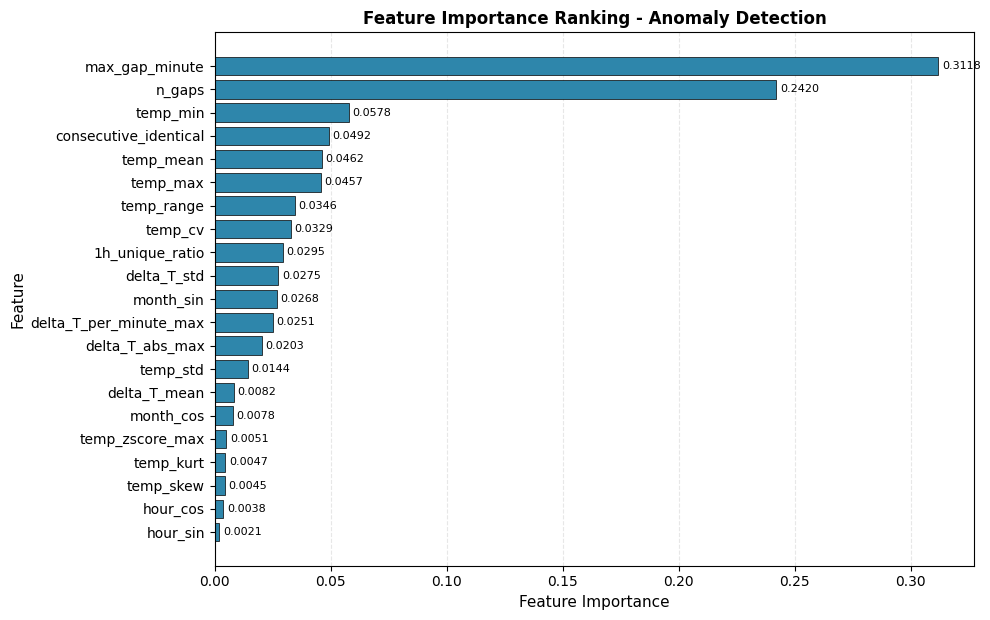

In [48]:
# ============================================================
# STEP 4: FEATURE IMPORTANCE (RF proxy) — Stage 1
# ============================================================
rf_proxy_s1 = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_proxy_s1.fit(X_val_s1_scaled, y_val_s1)

importance_s1 = pd.DataFrame({
    'feature': X_val_s1_scaled.columns,
    'importance': rf_proxy_s1.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(importance_s1.to_string(index=False))
importance_s1.to_excel(os.path.join(STAGE1_DIR, "feature_importance_s1.xlsx"), index=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, max(6, len(importance_s1) * 0.3)))
ax.barh(importance_s1['feature'][::-1], importance_s1['importance'][::-1],
        color='#2E86AB', edgecolor='black', linewidth=0.5)
for i, val in enumerate(importance_s1['importance'][::-1]):
    ax.text(val + max(importance_s1['importance']) * 0.005, i,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.set_title('Feature Importance Ranking - Anomaly Detection', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(os.path.join(STAGE1_DIR, "feature_importance_s1.png"), dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ============================================================
# STEP 5: STAGE 1 TUNING (IF, LOF, OC-SVM)
# ============================================================
N_VALUES_S1 = [7, 14, len(ALL_FEATURES)]
print(f"N values: {N_VALUES_S1}")

# Grids
IF_GRID = {
    'n_estimators':  [50, 100, 200, 500],
    'contamination': [0.001, 0.01, 0.05, 0.1],
}
LOF_GRID = {
    'n_neighbors':   [5, 10, 20, 50],
    'contamination': [0.001, 0.01, 0.05, 0.1],
}
OCSVM_GRID = {
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma':  ['auto', 'scale', 0.001, 0.01, 0.1],
    'nu':     [0.001, 0.01, 0.05, 0.1, 0.2],
}

print(f"\nIF configs per N    : {len(list(ParameterGrid(IF_GRID)))}")
print(f"LOF configs per N   : {len(list(ParameterGrid(LOF_GRID)))}")
print(f"OCSVM configs per N : {len(list(ParameterGrid(OCSVM_GRID)))}")

def eval_predictions(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }

# ── Tuning IF ──
print("\n--- Tuning Isolation Forest ---")
results_if = []
for n_feat in N_VALUES_S1:
    print(f"  N = {n_feat}")
    top_features = importance_s1.head(n_feat)['feature'].tolist()
    X_train_subset = X_train_s1_scaled[top_features].values
    X_val_subset   = X_val_s1_scaled[top_features].values
    for params in ParameterGrid(IF_GRID):
        try:
            m = IsolationForest(**params, random_state=RANDOM_STATE, n_jobs=-1)
            m.fit(X_train_subset)
            pred = (m.predict(X_val_subset) == -1).astype(int)
            results_if.append({'n_features': n_feat, **params, **eval_predictions(y_val_s1, pred)})
        except Exception as e:
            print(f"    [FAIL] {params} → {type(e).__name__}: {e}")

df_if = pd.DataFrame(results_if)

# ── Tuning LOF ──
print("\n--- Tuning LOF ---")
results_lof = []
for n_feat in N_VALUES_S1:
    print(f"  N = {n_feat}")
    top_features = importance_s1.head(n_feat)['feature'].tolist()
    X_train_subset = X_train_s1_scaled[top_features].values
    X_val_subset   = X_val_s1_scaled[top_features].values
    for params in ParameterGrid(LOF_GRID):
        try:
            m = LocalOutlierFactor(**params, novelty=True, n_jobs=-1)
            m.fit(X_train_subset)
            pred = (m.predict(X_val_subset) == -1).astype(int)
            results_lof.append({'n_features': n_feat, **params, **eval_predictions(y_val_s1, pred)})
        except Exception as e:
            print(f"    [FAIL] {params} → {type(e).__name__}: {e}")

df_lof = pd.DataFrame(results_lof)

# ── Tuning OC-SVM ──
print("\n--- Tuning OC-SVM ---")
results_ocsvm = []
for n_feat in N_VALUES_S1:
    print(f"  N = {n_feat}")
    top_features = importance_s1.head(n_feat)['feature'].tolist()
    X_train_subset = X_train_s1_scaled[top_features].values
    X_val_subset   = X_val_s1_scaled[top_features].values
    for params in ParameterGrid(OCSVM_GRID):
        try:
            m = OneClassSVM(**params)
            m.fit(X_train_subset)
            pred = (m.predict(X_val_subset) == -1).astype(int)
            results_ocsvm.append({'n_features': n_feat, **params, **eval_predictions(y_val_s1, pred)})
        except Exception as e:
            print(f"    [FAIL] {params} → {type(e).__name__}: {e}")

df_ocsvm = pd.DataFrame(results_ocsvm)

# Save raw tuning results
df_if.to_excel(os.path.join(STAGE1_DIR, "tuning_if.xlsx"), index=False)
df_lof.to_excel(os.path.join(STAGE1_DIR, "tuning_lof.xlsx"), index=False)
df_ocsvm.to_excel(os.path.join(STAGE1_DIR, "tuning_ocsvm.xlsx"), index=False)
print("\n[OK] Raw tuning results disimpan.")

N values: [7, 14, 21]

IF configs per N    : 16
LOF configs per N   : 16
OCSVM configs per N : 75

--- Tuning Isolation Forest ---
  N = 7
  N = 14
  N = 21

--- Tuning LOF ---
  N = 7
  N = 14
  N = 21

--- Tuning OC-SVM ---
  N = 7
  N = 14
  N = 21

[OK] Raw tuning results disimpan.


In [17]:
# ============================================================
# STEP 5b: BEST CONFIG PER N — Stage 1 (pilih ACCURACY tertinggi per N)
# ============================================================
# Format output sesuai permintaan:
#   N = 10, n_estimators=..., recall=..., precision=..., accuracy=..., f1=...
# Lalu BEST OVERALL = N dengan accuracy tertinggi (tetep tampil semua metrik).
# ============================================================

def best_per_n_s1(df_tuning, model_name, param_cols):
    """Untuk tiap nilai n_features, ambil 1 row dengan accuracy tertinggi."""
    df = df_tuning.copy()
    df = df.sort_values(['n_features', 'accuracy'], ascending=[True, False])
    best = df.groupby('n_features', as_index=False).head(1).reset_index(drop=True)
    return best

def print_best_per_n(df_best, model_name, param_cols):
    print("\n" + "=" * 80)
    print(f" BEST CONFIG PER N — {model_name} (sorted by ACCURACY)")
    print("=" * 80)
    for _, row in df_best.iterrows():
        n = int(row['n_features'])
        params_str = ", ".join([f"{c}={row[c]}" for c in param_cols])
        print(f"N = {n:>3}  |  {params_str}  |  "
              f"recall={row['recall']:.4f}, precision={row['precision']:.4f}, "
              f"accuracy={row['accuracy']:.4f}, f1={row['f1']:.4f}")
    # Best overall = baris dgn accuracy paling tinggi
    best_row = df_best.sort_values('accuracy', ascending=False).iloc[0]
    n_best = int(best_row['n_features'])
    print(f"\n>>> BEST OVERALL ({model_name}): N = {n_best}, "
          f"accuracy={best_row['accuracy']:.4f}  "
          f"(precision={best_row['precision']:.4f}, recall={best_row['recall']:.4f}, "
          f"f1={best_row['f1']:.4f})")
    return best_row

# IF
best_if_per_n = best_per_n_s1(df_if, 'Isolation Forest', ['n_estimators', 'contamination'])
best_if = print_best_per_n(best_if_per_n, 'Isolation Forest', ['n_estimators', 'contamination'])

# LOF
best_lof_per_n = best_per_n_s1(df_lof, 'LOF', ['n_neighbors', 'contamination'])
best_lof = print_best_per_n(best_lof_per_n, 'LOF', ['n_neighbors', 'contamination'])

# OC-SVM
best_ocsvm_per_n = best_per_n_s1(df_ocsvm, 'OC-SVM', ['kernel', 'gamma', 'nu'])
best_ocsvm = print_best_per_n(best_ocsvm_per_n, 'OC-SVM', ['kernel', 'gamma', 'nu'])

# Save best-per-N ke Excel
with pd.ExcelWriter(os.path.join(STAGE1_DIR, "best_config_per_n_s1.xlsx"), engine='openpyxl') as writer:
    best_if_per_n.to_excel(writer,   sheet_name='IF',     index=False)
    best_lof_per_n.to_excel(writer,  sheet_name='LOF',    index=False)
    best_ocsvm_per_n.to_excel(writer, sheet_name='OC-SVM', index=False)
print("\n[SAVED] best_config_per_n_s1.xlsx")


 BEST CONFIG PER N — Isolation Forest (sorted by ACCURACY)
N =   7  |  n_estimators=500.0, contamination=0.05  |  recall=0.9887, precision=0.9849, accuracy=0.9797, f1=0.9868
N =  14  |  n_estimators=500.0, contamination=0.1  |  recall=0.9276, precision=0.9696, accuracy=0.9222, f1=0.9482
N =  21  |  n_estimators=500.0, contamination=0.1  |  recall=0.8184, precision=0.9672, accuracy=0.8393, f1=0.8866

>>> BEST OVERALL (Isolation Forest): N = 7, accuracy=0.9797  (precision=0.9849, recall=0.9887, f1=0.9868)

 BEST CONFIG PER N — LOF (sorted by ACCURACY)
N =   7  |  n_neighbors=10.0, contamination=0.05  |  recall=0.9569, precision=0.9825, accuracy=0.9538, f1=0.9695
N =  14  |  n_neighbors=10.0, contamination=0.1  |  recall=0.9624, precision=0.9692, accuracy=0.9476, f1=0.9658
N =  21  |  n_neighbors=5.0, contamination=0.1  |  recall=0.9482, precision=0.9649, accuracy=0.9337, f1=0.9565

>>> BEST OVERALL (LOF): N = 7, accuracy=0.9538  (precision=0.9825, recall=0.9569, f1=0.9695)

 BEST CONFIG

In [18]:
# ============================================================
# STEP 6: STAGE 1 FINAL EVALUATION (TRAIN/VAL/TEST)
# ============================================================
# Pakai n_features dari best config (accuracy tertinggi) masing-masing model.

# IF Final
top_feat_if = importance_s1.head(int(best_if['n_features']))['feature'].tolist()
X_train_if = X_train_s1_scaled[top_feat_if].values
X_val_if   = X_val_s1_scaled[top_feat_if].values
X_test_if  = X_test_s1_scaled[top_feat_if].values

if_final = IsolationForest(
    n_estimators=int(best_if['n_estimators']),
    contamination=best_if['contamination'],
    random_state=RANDOM_STATE, n_jobs=-1
)
if_final.fit(X_train_if)

# LOF Final
top_feat_lof = importance_s1.head(int(best_lof['n_features']))['feature'].tolist()
X_train_lof = X_train_s1_scaled[top_feat_lof].values
X_val_lof   = X_val_s1_scaled[top_feat_lof].values
X_test_lof  = X_test_s1_scaled[top_feat_lof].values

lof_final = LocalOutlierFactor(
    n_neighbors=int(best_lof['n_neighbors']),
    contamination=best_lof['contamination'],
    novelty=True, n_jobs=-1
)
lof_final.fit(X_train_lof)

# OC-SVM Final
top_feat_ocsvm = importance_s1.head(int(best_ocsvm['n_features']))['feature'].tolist()
X_train_ocsvm = X_train_s1_scaled[top_feat_ocsvm].values
X_val_ocsvm   = X_val_s1_scaled[top_feat_ocsvm].values
X_test_ocsvm  = X_test_s1_scaled[top_feat_ocsvm].values

ocsvm_final = OneClassSVM(
    kernel=best_ocsvm['kernel'],
    gamma=best_ocsvm['gamma'],
    nu=best_ocsvm['nu']
)
ocsvm_final.fit(X_train_ocsvm)

def predict_oc(model, X):
    return (model.predict(X) == -1).astype(int)

preds_s1 = {
    'Isolation Forest': {
        'train': predict_oc(if_final, X_train_if),
        'val':   predict_oc(if_final, X_val_if),
        'test':  predict_oc(if_final, X_test_if),
    },
    'LOF': {
        'train': predict_oc(lof_final, X_train_lof),
        'val':   predict_oc(lof_final, X_val_lof),
        'test':  predict_oc(lof_final, X_test_lof),
    },
    'OC-SVM': {
        'train': predict_oc(ocsvm_final, X_train_ocsvm),
        'val':   predict_oc(ocsvm_final, X_val_ocsvm),
        'test':  predict_oc(ocsvm_final, X_test_ocsvm),
    },
}

y_splits_s1 = {'train': y_train_s1, 'val': y_val_s1, 'test': y_test_s1}
LABELS_S1 = ['NORMAL', 'ABNORMAL']

# Print metrics
summary_s1 = []
for model_name, splits in preds_s1.items():
    print("\n" + "=" * 70)
    print(f" {model_name}")
    print("=" * 70)
    for split_name, y_pred in splits.items():
        y_true = y_splits_s1[split_name]
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if split_name == 'train':
            tn, fp = cm[0, 0], cm[0, 1]
            tp, fn = 0, 0
        else:
            tn, fp, fn, tp = cm.ravel()

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)

        print(f"\n--- {split_name.upper()} ---")
        print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
        print(f"  Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
        if split_name != 'train':
            print(classification_report(y_true, y_pred, target_names=LABELS_S1, zero_division=0, digits=4))
        else:
            print("  [INFO] Train set semua NORMAL → P/R/F1 untuk ABNORMAL = 0")

        summary_s1.append({
            'model': model_name, 'split': split_name,
            'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
            'accuracy': round(acc, 4), 'precision': round(prec, 4),
            'recall': round(rec, 4), 'f1': round(f1, 4),
        })

df_summary_s1 = pd.DataFrame(summary_s1)
print("\n" + "=" * 80)
print(" RINGKASAN STAGE 1 (IF / LOF / OC-SVM)")
print("=" * 80)
print(df_summary_s1.to_string(index=False))


 Isolation Forest

--- TRAIN ---
  TP=0  TN=22705  FP=1195  FN=0
  Accuracy: 0.9500  Precision: 0.0000  Recall: 0.0000  F1: 0.0000
  [INFO] Train set semua NORMAL → P/R/F1 untuk ABNORMAL = 0

--- VAL ---
  TP=16719  TN=4865  FP=256  FN=191
  Accuracy: 0.9797  Precision: 0.9849  Recall: 0.9887  F1: 0.9868
              precision    recall  f1-score   support

      NORMAL     0.9622    0.9500    0.9561      5121
    ABNORMAL     0.9849    0.9887    0.9868     16910

    accuracy                         0.9797     22031
   macro avg     0.9736    0.9694    0.9714     22031
weighted avg     0.9796    0.9797    0.9797     22031


--- TEST ---
  TP=16724  TN=4859  FP=264  FN=186
  Accuracy: 0.9796  Precision: 0.9845  Recall: 0.9890  F1: 0.9867
              precision    recall  f1-score   support

      NORMAL     0.9631    0.9485    0.9557      5123
    ABNORMAL     0.9845    0.9890    0.9867     16910

    accuracy                         0.9796     22033
   macro avg     0.9738    0.968


=== Isolation Forest ===


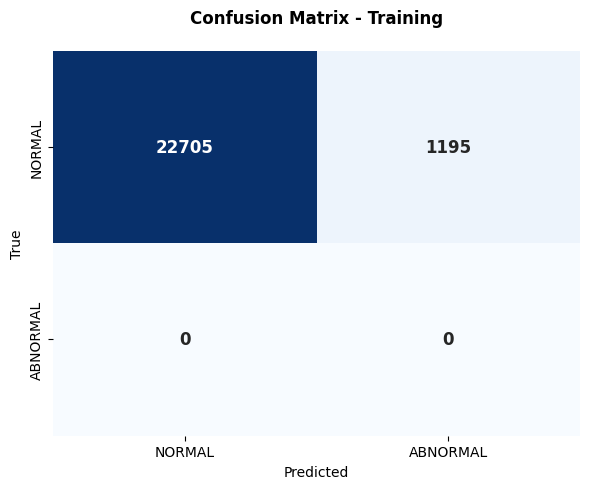

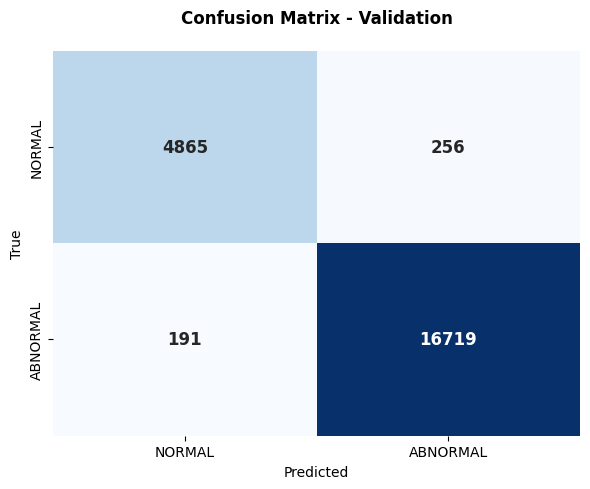

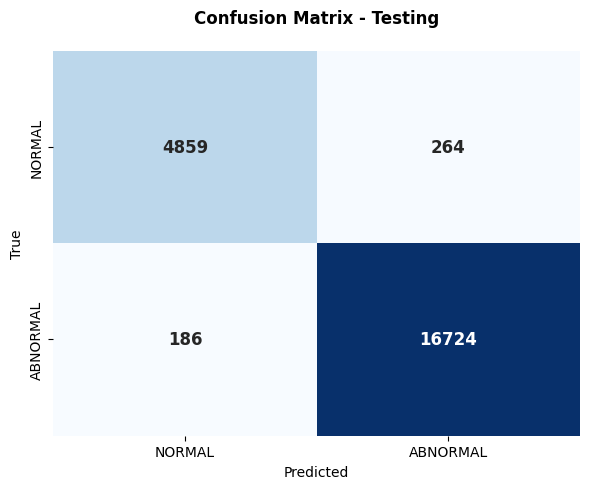


=== LOF ===


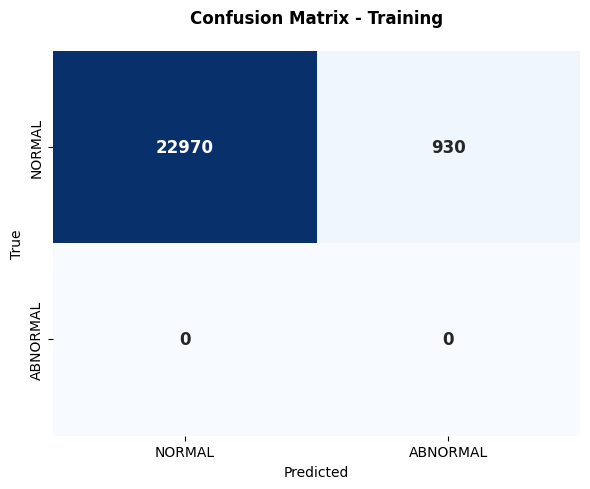

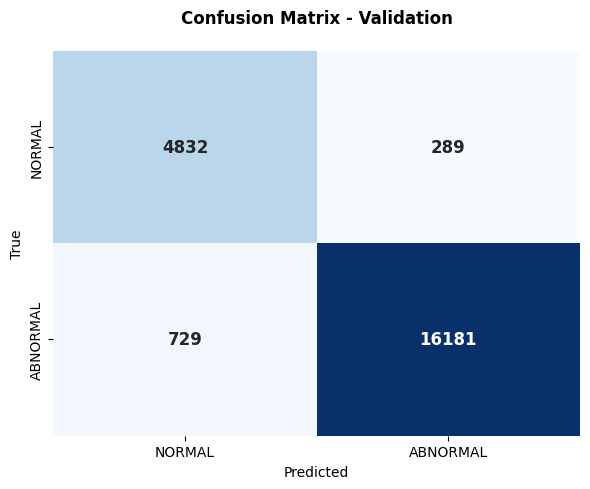

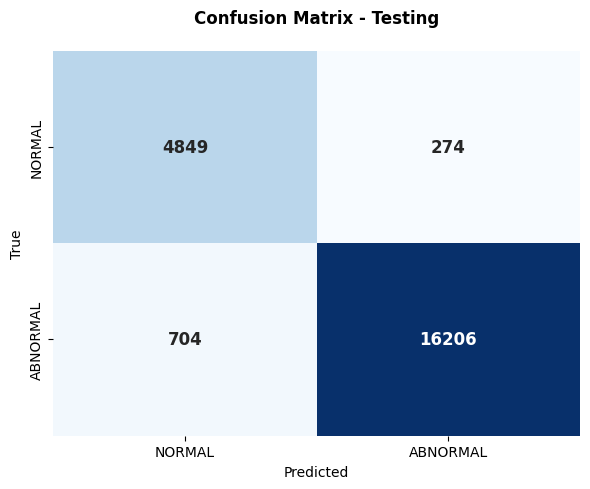


=== OC-SVM ===


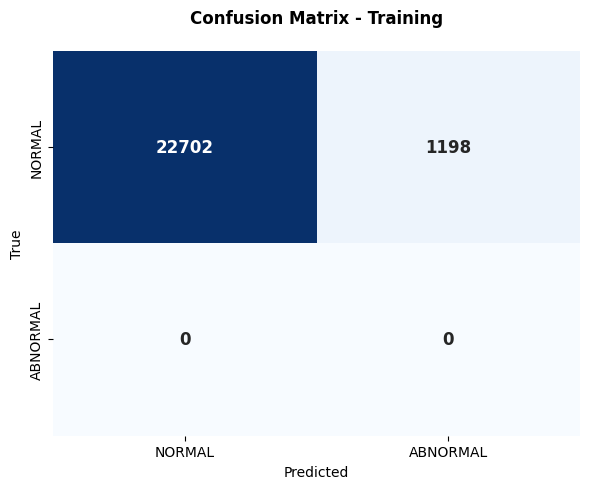

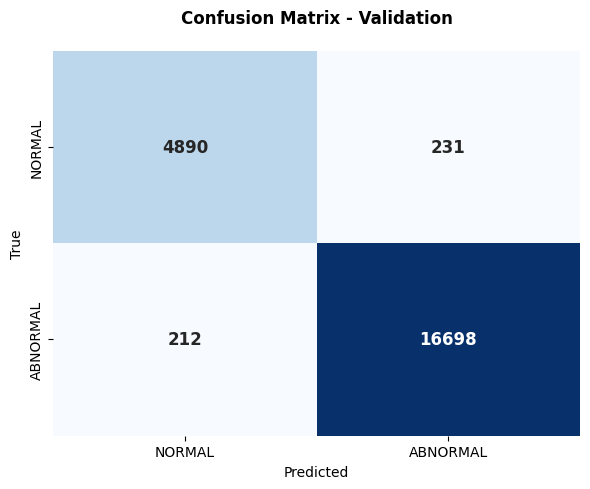

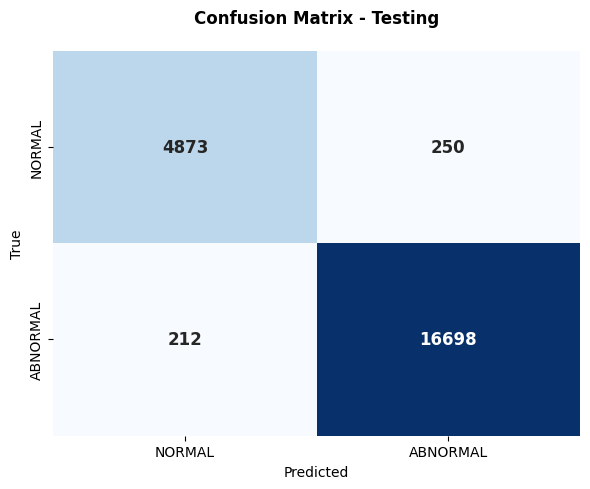

In [21]:
def plot_cm_separate(y_true, y_pred, labels, split_name, model_name,
                      save_dir, save_prefix, cmap='Blues', figsize=(6, 5)):

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))

    split_title_map = {
        'train': 'Training',
        'val': 'Validation',
        'test': 'Testing'
    }

    split_title = split_title_map.get(split_name, split_name.title())

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=False,
        annot_kws={'size': 12, 'fontweight': 'bold'}
    )

    ax.set_title(
        f'Confusion Matrix - {split_title}',
        fontsize=12,
        fontweight='bold',
        pad=20
    )

    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

    plt.tight_layout()

    save_path = os.path.join(
        save_dir,
        f"{save_prefix}_cm_{split_name}.png"
    )

    plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

model_save_prefix = {
    'Isolation Forest': 'if',
    'LOF': 'lof',
    'OC-SVM': 'ocsvm'
}

model_cmap = {
    'Isolation Forest': 'Blues',
    'LOF': 'Blues',
    'OC-SVM': 'Blues'
}


for model_name, splits in preds_s1.items():

    print(f"\n=== {model_name} ===")

    for split_name in ['train', 'val', 'test']:

        plot_cm_separate(
            y_true=y_splits_s1[split_name],
            y_pred=splits[split_name],
            labels=LABELS_S1,
            split_name=split_name,
            model_name=model_name,
            save_dir=STAGE1_DIR,
            save_prefix=model_save_prefix[model_name],
            cmap=model_cmap[model_name]
        )

In [33]:
# ============================================================
# STEP 7a: ONE-CLASS DNN — AUTOENCODER ADAPTIF PER N
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import time


# >>> N values yang dicoba — silakan disesuaikan (mengikuti N_VALUES_S1) <
N_VALUES_DNN = [7, 14, 21]

# Konfigurasi training
CONFIG_DNN = {
    'lr':         1e-3,
    'batch_size': 256,
    'max_epochs': 300,
    'patience':   10,
    'seed':       42,    # 1 run per N → 1 seed
}

# ============================================================
# ARSITEKTUR ADAPTIF
# Hidden layers menyesuaikan jumlah N input.
# Bottleneck = max(2, N // 3) → kompresi sekitar 67-70% di semua N.
# Hidden     = [N×3, N×2, N] → encoder expand-then-compress.
# ============================================================
def get_architecture(input_dim):
    bottleneck = max(2, input_dim // 3)
    hidden_layers = [input_dim * 3, input_dim * 2, input_dim]
    return hidden_layers, bottleneck

def build_autoencoder(input_dim, learning_rate):
    """
    Adaptive Autoencoder:
      Encoder : input → N×3 → N×2 → N → bottleneck
      Decoder : bottleneck → N → N×2 → N×3 → input
    """
    hidden_layers, bottleneck = get_architecture(input_dim)
    inputs = tf.keras.Input(shape=(input_dim,), name='input')
    x = inputs
    for h in hidden_layers:
        x = tf.keras.layers.Dense(h, activation='relu')(x)
    encoded = tf.keras.layers.Dense(bottleneck, activation='relu', name='bottleneck')(x)
    x = encoded
    for h in reversed(hidden_layers):
        x = tf.keras.layers.Dense(h, activation='relu')(x)
    decoded = tf.keras.layers.Dense(input_dim, activation='linear', name='output')(x)
    ae = tf.keras.Model(inputs, decoded, name=f'ae_n{input_dim}')
    ae.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse'
    )
    return ae

# Preview arsitektur per N
print("=" * 65)
print(" ARSITEKTUR ADAPTIF PER N")
print("=" * 65)
print(f"{'N':<6}{'Hidden':<25}{'Bottleneck':<12}{'Compression':<12}")
print("-" * 65)
for n in N_VALUES_DNN:
    hidden, b = get_architecture(n)
    compr = (1 - b / n) * 100
    print(f"{n:<6}{str(hidden):<25}{b:<12}{compr:>5.1f}%")

 ARSITEKTUR ADAPTIF PER N
N     Hidden                   Bottleneck  Compression 
-----------------------------------------------------------------
7     [21, 14, 7]              2            71.4%
14    [42, 28, 14]             4            71.4%
21    [63, 42, 21]             7            66.7%


In [34]:
# ============================================================
# STEP 7b: HELPER FUNCTIONS
# ============================================================
def get_recon_error(model, X):
    """Per-sample MSE antara input dan rekonstruksi."""
    X_pred = model.predict(X, verbose=0)
    return np.mean((X - X_pred) ** 2, axis=1)


def optimize_threshold_acc(err_train, err_val, y_val):
    """
    Cari threshold yang maximize ACC di validation set.
    Scan percentile 50-99.5 (step 0.5)
    dari distribusi training reconstruction error.
    """
    percentiles = np.arange(50, 100, 0.5)

    best_acc = 0.0
    best_thresh = 0.0

    for p in percentiles:
        thresh = np.percentile(err_train, p)

        pred = (err_val > thresh).astype(int)

        acc = accuracy_score(y_val, pred)

        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh

    return best_thresh, best_acc


print("[OK] Helper functions ready: get_recon_error, optimize_threshold_acc")

[OK] Helper functions ready: get_recon_error, optimize_threshold_acc


In [35]:
# ============================================================
# STEP 7c: MAIN LOOP — TRAIN AUTOENCODER PER N (1 run/N)
# Threshold di-optimize di validation (scan percentile, max ACC)
# ============================================================
results_dnn = []
models_dnn = {}
preds_dnn_per_n = {}
errs_dnn_per_n = {}

t_start = time.time()

for n_feat in N_VALUES_DNN:

    print(f"\n{'='*60}")
    print(f"  N = {n_feat} features")
    print(f"{'='*60}")

    # ========================================================
    # Subset top-N feature
    # ========================================================
    top_features = importance_s1.head(n_feat)['feature'].tolist()

    print(f"  Features: {top_features}")

    X_train_n = X_train_s1_scaled[top_features].values.astype('float32')
    X_val_n   = X_val_s1_scaled[top_features].values.astype('float32')
    X_test_n  = X_test_s1_scaled[top_features].values.astype('float32')

    X_val_normal_n = X_val_n[y_val_s1 == 0]

    print(f"  Shape: train={X_train_n.shape}, val={X_val_n.shape}, test={X_test_n.shape}")

    # ========================================================
    # Build autoencoder
    # ========================================================
    tf.keras.utils.set_random_seed(CONFIG_DNN['seed'])

    ae = build_autoencoder(n_feat, CONFIG_DNN['lr'])

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=CONFIG_DNN['patience'],
        restore_best_weights=True,
        verbose=0
    )

    # ========================================================
    # Train
    # ========================================================
    history = ae.fit(
        X_train_n,
        X_train_n,
        epochs=CONFIG_DNN['max_epochs'],
        batch_size=CONFIG_DNN['batch_size'],
        validation_data=(X_val_normal_n, X_val_normal_n),
        callbacks=[early_stop],
        verbose=2
    )

    stopped_at = (
        early_stop.stopped_epoch
        if early_stop.stopped_epoch > 0
        else CONFIG_DNN['max_epochs']
    )

    # ========================================================
    # Reconstruction error
    # ========================================================
    err_train = get_recon_error(ae, X_train_n)
    err_val   = get_recon_error(ae, X_val_n)
    err_test  = get_recon_error(ae, X_test_n)

    # ========================================================
    # Optimize threshold (MAX VALIDATION ACCURACY)
    # ========================================================
    threshold, val_acc = optimize_threshold_acc(
        err_train,
        err_val,
        y_val_s1
    )

    # ========================================================
    # Prediction
    # ========================================================
    pred_train = (err_train > threshold).astype(int)
    pred_val   = (err_val   > threshold).astype(int)
    pred_test  = (err_test  > threshold).astype(int)

    # ========================================================
    # Test metrics
    # ========================================================
    acc_test  = accuracy_score(y_test_s1, pred_test)

    prec_test = precision_score(
        y_test_s1,
        pred_test,
        zero_division=0
    )

    rec_test = recall_score(
        y_test_s1,
        pred_test,
        zero_division=0
    )

    f1_test = f1_score(
        y_test_s1,
        pred_test,
        zero_division=0
    )

    # ========================================================
    # Save model & predictions
    # ========================================================
    models_dnn[n_feat] = ae

    preds_dnn_per_n[n_feat] = {
        'train': pred_train,
        'val': pred_val,
        'test': pred_test
    }

    errs_dnn_per_n[n_feat] = {
        'train': err_train,
        'val': err_val,
        'test': err_test,
        'threshold': threshold
    }

    # ========================================================
    # Save results
    # ========================================================
    results_dnn.append({
        'N_features': n_feat,
        'Stopped_Epoch': stopped_at,
        'Threshold': round(threshold, 6),
        'Val_Accuracy': round(val_acc, 4),
        'Test_Accuracy': round(acc_test, 4),
        'Test_Precision': round(prec_test, 4),
        'Test_Recall': round(rec_test, 4),
        'Test_F1': round(f1_test, 4),
    })

    # ========================================================
    # Print summary
    # ========================================================
    print(f"\n  ── Result N={n_feat} ──")
    print(f"  Stopped @ epoch : {stopped_at}")
    print(f"  Threshold       : {threshold:.6f}")
    print(f"  Val Accuracy    : {val_acc:.4f}")

    print(
        f"  TEST: "
        f"Acc={acc_test:.4f}  "
        f"P={prec_test:.4f}  "
        f"R={rec_test:.4f}  "
        f"F1={f1_test:.4f}"
    )

# ============================================================
# Total time
# ============================================================
elapsed = time.time() - t_start

print(f"\n[TIME] Total: {elapsed:.0f}s ({elapsed/60:.1f} menit)")

# ============================================================
# Save tuning results
# ============================================================
df_dnn_tuning = pd.DataFrame(results_dnn)

df_dnn_tuning.to_excel(
    os.path.join(STAGE1_DIR, "tuning_dnn.xlsx"),
    index=False
)


  N = 7 features
  Features: ['max_gap_minute', 'n_gaps', 'temp_min', 'consecutive_identical', 'temp_mean', 'temp_max', 'temp_range']
  Shape: train=(23900, 7), val=(22031, 7), test=(22033, 7)
Epoch 1/300
94/94 - 1s - loss: 0.7643 - val_loss: 0.4134 - 1s/epoch - 16ms/step
Epoch 2/300
94/94 - 1s - loss: 0.3345 - val_loss: 0.2466 - 633ms/epoch - 7ms/step
Epoch 3/300
94/94 - 1s - loss: 0.2805 - val_loss: 0.2284 - 780ms/epoch - 8ms/step
Epoch 4/300
94/94 - 1s - loss: 0.2601 - val_loss: 0.2089 - 689ms/epoch - 7ms/step
Epoch 5/300
94/94 - 1s - loss: 0.2434 - val_loss: 0.1998 - 713ms/epoch - 8ms/step
Epoch 6/300
94/94 - 1s - loss: 0.2302 - val_loss: 0.1856 - 601ms/epoch - 6ms/step
Epoch 7/300
94/94 - 0s - loss: 0.2188 - val_loss: 0.1818 - 438ms/epoch - 5ms/step
Epoch 8/300
94/94 - 0s - loss: 0.2050 - val_loss: 0.1642 - 430ms/epoch - 5ms/step
Epoch 9/300
94/94 - 0s - loss: 0.1905 - val_loss: 0.1557 - 400ms/epoch - 4ms/step
Epoch 10/300
94/94 - 0s - loss: 0.1756 - val_loss: 0.1473 - 386ms/epoc

 BEST CONFIG PER N — One-Class DNN (Autoencoder)
N =   7  |  threshold=0.218362, stopped@250.0  |  recall=0.9804, precision=0.9764, accuracy=0.9668, f1=0.9784
N =  14  |  threshold=0.026260, stopped@179.0  |  recall=0.9766, precision=0.9315, accuracy=0.9270, f1=0.9535
N =  21  |  threshold=0.034316, stopped@238.0  |  recall=0.9642, precision=0.9226, accuracy=0.9105, f1=0.9430

>>> BEST OVERALL DNN: N = 7, accuracy=0.9668  (precision=0.9764, recall=0.9804, f1=0.9784)
 One-Class DNN (Autoencoder) — Best N = 7

--- TRAIN ---
  TP=0  TN=21988  FP=1912  FN=0
  Accuracy: 0.9200  Precision: 0.0000  Recall: 0.0000  F1: 0.0000

--- VAL ---
  TP=16590  TN=4719  FP=402  FN=320
  Accuracy: 0.9672  Precision: 0.9763  Recall: 0.9811  F1: 0.9787
              precision    recall  f1-score   support

      NORMAL     0.9365    0.9215    0.9289      5121
    ABNORMAL     0.9763    0.9811    0.9787     16910

    accuracy                         0.9672     22031
   macro avg     0.9564    0.9513    0.95

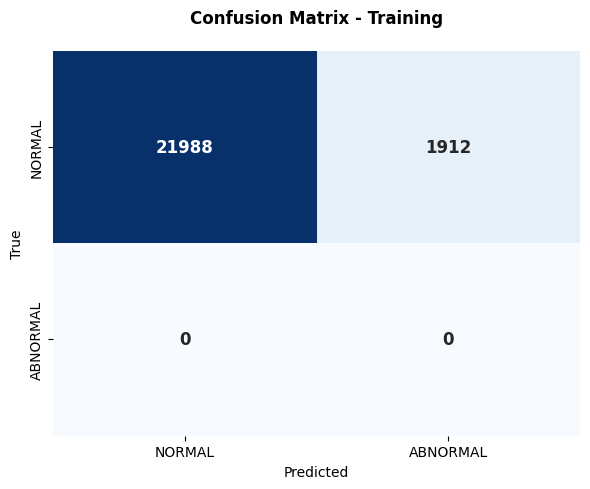

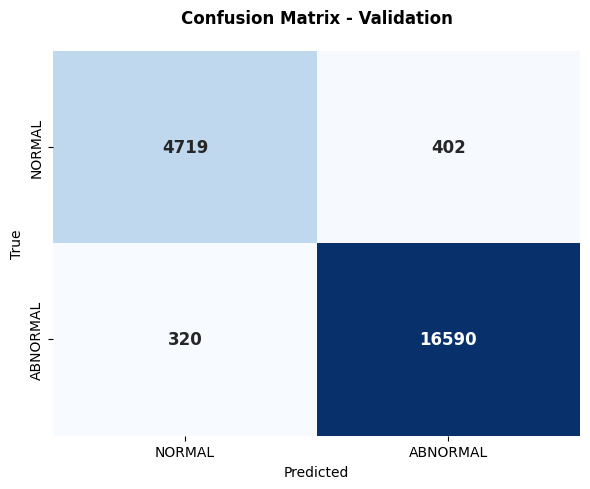

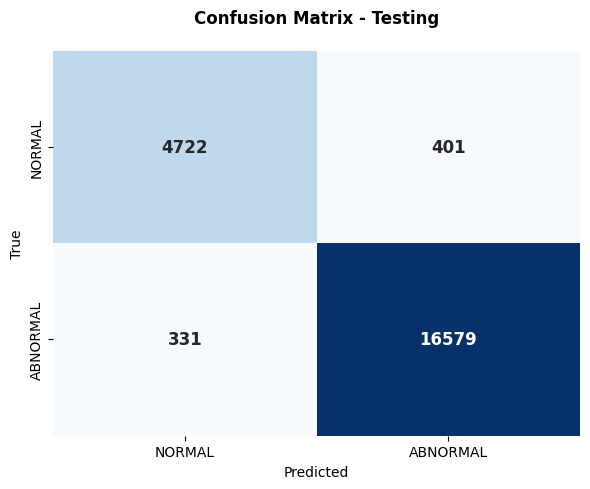

'\n# (Opsional) Plot distribusi reconstruction error untuk best N\nfig, ax = plt.subplots(figsize=(10, 5))\nerr_train = errs_best[\'train\']\nerr_val   = errs_best[\'val\']\nthreshold = errs_best[\'threshold\']\nax.hist(err_train, bins=60, alpha=0.5, label=\'Train (NORMAL)\', color=\'#2E86AB\', density=True)\nax.hist(err_val[y_val_s1 == 0], bins=60, alpha=0.5, label=\'Val NORMAL\', color=\'#06A77D\', density=True)\nax.hist(err_val[y_val_s1 == 1], bins=60, alpha=0.5, label=\'Val ABNORMAL\', color=\'#E63946\', density=True)\nax.axvline(threshold, color=\'black\', linestyle=\'--\', linewidth=2,\n           label=f\'Threshold={threshold:.4f}\')\nax.set_xlabel(\'Reconstruction Error (MSE)\')\nax.set_ylabel(\'Density\')\nax.set_title(f\'Distribusi Reconstruction Error (Best N = {best_n_dnn})\', fontweight=\'bold\')\nax.legend(); ax.grid(alpha=0.3)\nax.set_xlim(0, np.percentile(err_val, 99))\nplt.tight_layout()\nplt.savefig(os.path.join(STAGE1_DIR, f"dnn_n{best_n_dnn}_recon_error_dist.png"),\

In [37]:
# ============================================================
# STEP 7d: BEST PER-N OUTPUT + PILIH BEST OVERALL (by accuracy)
# ============================================================
print("=" * 90)
print(" BEST CONFIG PER N — One-Class DNN (Autoencoder)")
print("=" * 90)
for _, row in df_dnn_tuning.iterrows():
    n = int(row['N_features'])
    print(f"N = {n:>3}  |  threshold={row['Threshold']:.6f}, stopped@{row['Stopped_Epoch']}  |  "
          f"recall={row['Test_Recall']:.4f}, precision={row['Test_Precision']:.4f}, "
          f"accuracy={row['Test_Accuracy']:.4f}, f1={row['Test_F1']:.4f}")

# Best overall = N dengan accuracy tertinggi
best_dnn = df_dnn_tuning.sort_values('Val_Accuracy', ascending=False).iloc[0]
best_n_dnn = int(best_dnn['N_features'])
print(f"\n>>> BEST OVERALL DNN: N = {best_n_dnn}, "
      f"accuracy={best_dnn['Test_Accuracy']:.4f}  "
      f"(precision={best_dnn['Test_Precision']:.4f}, "
      f"recall={best_dnn['Test_Recall']:.4f}, f1={best_dnn['Test_F1']:.4f})")

# ============================================================
# STEP 7e: CONFUSION MATRIX TERPISAH untuk BEST N
# ============================================================
# Pakai prediksi dari best N (accuracy tertinggi)
preds_best = preds_dnn_per_n[best_n_dnn]
errs_best  = errs_dnn_per_n[best_n_dnn]

print("=" * 70)
print(f" One-Class DNN (Autoencoder) — Best N = {best_n_dnn}")
print("=" * 70)

summary_dnn = []
for split_name in ['train', 'val', 'test']:
    y_true = y_splits_s1[split_name]
    y_pred = preds_best[split_name]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if split_name == 'train':
        tn, fp = cm[0, 0], cm[0, 1]
        tp, fn = 0, 0
    else:
        tn, fp, fn, tp = cm.ravel()

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- {split_name.upper()} ---")
    print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    print(f"  Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    if split_name != 'train':
        print(classification_report(y_true, y_pred, target_names=LABELS_S1, zero_division=0, digits=4))

    summary_dnn.append({
        'model': f'One-Class DNN (AE) N={best_n_dnn}', 'split': split_name,
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'accuracy': round(acc, 4), 'precision': round(prec, 4),
        'recall': round(rec, 4), 'f1': round(f1, 4),
    })

df_summary_dnn = pd.DataFrame(summary_dnn)
df_summary_dnn.to_excel(os.path.join(STAGE1_DIR, "summary_dnn.xlsx"), index=False)

# Plot CM terpisah
print(f"\n=== Confusion Matrix DNN (Best N = {best_n_dnn}) — separate per split ===")
for split_name in ['train', 'val', 'test']:
    plot_cm_separate(
        y_true=y_splits_s1[split_name],
        y_pred=preds_best[split_name],
        labels=LABELS_S1,
        split_name=split_name,
        model_name=f'One-Class DNN (AE) N={best_n_dnn}',
        save_dir=STAGE1_DIR,
        save_prefix=f'dnn_n{best_n_dnn}',
        cmap='Blues'
    )

'''
# (Opsional) Plot distribusi reconstruction error untuk best N
fig, ax = plt.subplots(figsize=(10, 5))
err_train = errs_best['train']
err_val   = errs_best['val']
threshold = errs_best['threshold']
ax.hist(err_train, bins=60, alpha=0.5, label='Train (NORMAL)', color='#2E86AB', density=True)
ax.hist(err_val[y_val_s1 == 0], bins=60, alpha=0.5, label='Val NORMAL', color='#06A77D', density=True)
ax.hist(err_val[y_val_s1 == 1], bins=60, alpha=0.5, label='Val ABNORMAL', color='#E63946', density=True)
ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold={threshold:.4f}')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title(f'Distribusi Reconstruction Error (Best N = {best_n_dnn})', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(0, np.percentile(err_val, 99))
plt.tight_layout()
plt.savefig(os.path.join(STAGE1_DIR, f"dnn_n{best_n_dnn}_recon_error_dist.png"),
            dpi=150, bbox_inches='tight')
plt.show()
'''

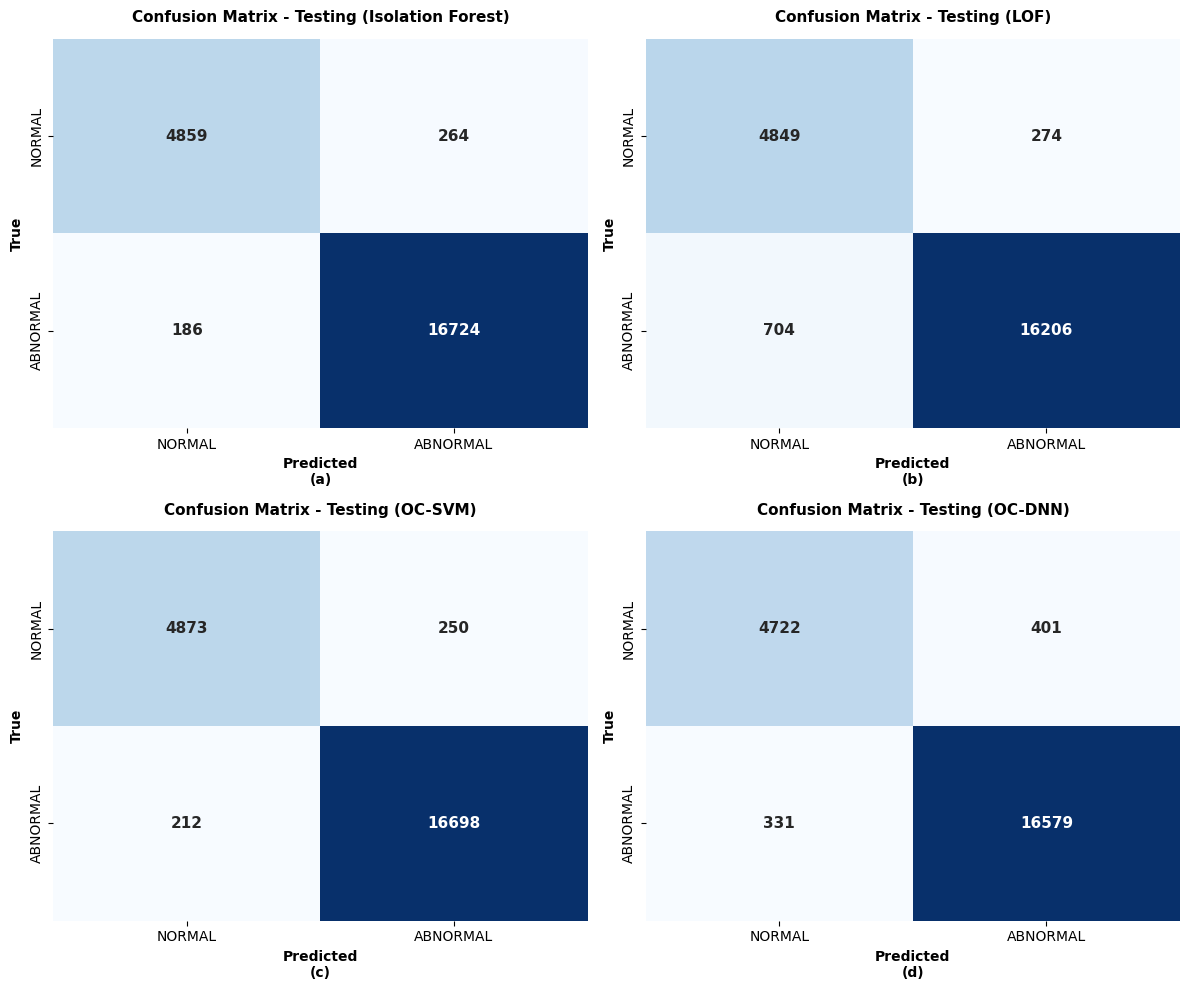

In [46]:
# ============================================================
# CONFUSION MATRIX — TESTING ONLY (ALL MODELS)

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

# ============================================================
# MODEL CONFIG
# ============================================================

models_info = [

    {
        'ax_idx': 0,
        'label': '(a)',
        'title': 'Isolation Forest',
        'y_pred': preds_s1['Isolation Forest']['test']
    },

    {
        'ax_idx': 1,
        'label': '(b)',
        'title': 'LOF',
        'y_pred': preds_s1['LOF']['test']
    },

    {
        'ax_idx': 2,
        'label': '(c)',
        'title': 'OC-SVM',
        'y_pred': preds_s1['OC-SVM']['test']
    },

    {
        'ax_idx': 3,
        'label': '(d)',
        'title': 'OC-DNN',
        'y_pred': preds_best['test']
    }
]

# ============================================================
# PLOT EACH CONFUSION MATRIX
# ============================================================

for item in models_info:

    ax = axes[item['ax_idx']]

    cm = confusion_matrix(
        y_splits_s1['test'],
        item['y_pred'],
        labels=list(range(len(LABELS_S1)))
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=LABELS_S1,
        yticklabels=LABELS_S1,
        cbar=False,
        ax=ax,
        annot_kws={
            'size': 11,
            'fontweight': 'bold'
        }
    )

    # Title
    ax.set_title(
        f'Confusion Matrix - Testing ({item["title"]})',
        fontsize=11,
        fontweight='bold',
        pad=12
    )

    # Axis labels
    ax.set_ylabel(
        'True',
        fontsize=10,
        fontweight='bold'
    )

    ax.set_xlabel(
        f'Predicted\n{item["label"]}',
        fontsize=10,
        fontweight='bold'
    )

# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout()
plt.show()
